# EDA – CHRONO24 PRICE PREDICTION MODELS

# Load Data and Inspect

In [272]:
!pip install kagglehub -q

In [273]:

import kagglehub
import pandas as pd
import numpy as np
import warnings
import os
import re


pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("philmorekoung11/luxury-watch-listings")
print(f"Dataset downloaded to: {path}")

df = pd.read_csv(f"{path}/Watches.csv")

print(f"Shape: {df.shape}")
print(f"\nFull duplicates: {df.duplicated().sum()}")
df.head()

Using Colab cache for faster access to the 'luxury-watch-listings' dataset.
Dataset downloaded to: /kaggle/input/luxury-watch-listings
Shape: (284491, 14)

Full duplicates: 0


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph\n'25th Anniversary',"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Blue Dial,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Dial - BV Limited Edition 10 Dlc - Pvd,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwinding Chronograph Blue Dial,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph\nCronografo 42mm Panda Dial 26170STOO1000ST01,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


In [274]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:10])


--- Unnamed: 0 ---
[0 1 2 3 4 5 6 7 8 9]

--- name ---
["Audemars Piguet Royal Oak Offshore Chronograph\n'25th Anniversary'"
 'Audemars Piguet Royal Oak Selfwinding\n39mm Blue Dial'
 'Audemars Piguet Royal Oak Chronograph\nBlue Dial - BV Limited Edition 10 Dlc - Pvd'
 'Audemars Piguet Royal Oak Chronograph\nSelfwinding Chronograph Blue Dial'
 'Audemars Piguet Royal Oak Offshore Chronograph\nCronografo 42mm Panda Dial 26170STOO1000ST01'
 'Audemars Piguet Royal Oak Offshore Diver\n2018 Unworn Royal Oak Offshore Diver (Limit 200pics)'
 'Audemars Piguet Royal Oak Offshore Diver Chronograph\n26703ST.OO.A051CA.01'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26470IO.OO.A006CA.01'
 'Audemars Piguet Royal Oak Dual Time\n26120ST.OO.1220ST.03'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26401.RO.OO.A002.CA.01']

--- price ---
['$43,500' '$71,500' '$79,191' '$108,000' '$27,500' '$41,000' '$37,800'
 '$32,182' '$36,473' '$35,000']

--- brand ---
['Audemars Piguet' 'Cartier' 'Tudor' 'Bre

In [275]:
from datetime import datetime

CURRENT_YEAR = datetime.now().year

# Cleaning

In [276]:
print(f"Shape before cleaning: {df.shape}")

df = df.drop(columns=['Unnamed: 0'])

df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

df['condition'] = df['condition'].fillna(df['cond'])
df = df.drop(columns=['cond'])

df['yop_approx'] = df['yop'].str.contains('Approximation', na=False).astype(int)
df['yop'] = pd.to_numeric(df['yop'].str.extract(r'(\d{4})')[0], errors='coerce')

df['size_mm'] = pd.to_numeric(df['size'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df = df.drop(columns=['size'])

for col in ['sex', 'condition', 'model', 'brand']:
    df[col] = df[col].fillna('Unknown')

df = df.drop_duplicates(subset=['name', 'ref', 'price', 'brand'], keep='first')

print(f"Shape after cleaning: {df.shape}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")
print(f"\nPrice stats:\n{df['price'].describe()}")
print(f"\nyop stats:\n{df['yop'].describe()}")
print(f"\nsize_mm stats:\n{df['size_mm'].describe()}")

Shape before cleaning: (284491, 14)
Shape after cleaning: (247823, 13)

Missing values (%):
name          21.44
price          0.00
brand          0.00
model          0.00
ref           15.79
mvmt          67.43
casem         58.59
bracem        62.34
yop           34.34
sex            0.00
condition      0.00
yop_approx     0.00
size_mm        8.31
dtype: float64

Price stats:
count    2.478230e+05
mean     1.864181e+04
std      6.775256e+04
min      1.000000e+01
25%      2.850000e+03
50%      6.517000e+03
75%      1.568800e+04
max      9.000000e+06
Name: price, dtype: float64

yop stats:
count    162719.000000
mean       2009.034065
std          20.881424
min        1559.000000
25%        2003.000000
50%        2020.000000
75%        2023.000000
max        2024.000000
Name: yop, dtype: float64

size_mm stats:
count    2.272180e+05
mean     3.801021e+08
std      2.867050e+10
min      0.000000e+00
25%      3.600000e+01
50%      4.000000e+01
75%      4.200000e+01
max      2.724317e+12
N

In [277]:
key_cols = ['price', 'brand', 'mvmt', 'casem', 'bracem']

before_rows = len(df)
df = df.copy()
df = df.dropna(subset=key_cols)

print(f"Rows before: {before_rows}")
print(f"Rows after dropping rows with any gap in key columns: {len(df)}")
print(f"Rows removed: {before_rows - len(df)}")

Rows before: 247823
Rows after dropping rows with any gap in key columns: 67238
Rows removed: 180585


In [278]:
print(f"Full dataset: {len(df)}")

df = df[
    (df['casem'] != 'Unknown') &
    (df['bracem'] != 'Unknown') &
    (df['mvmt'] != 'Unknown')
].copy()

print(f"Complete-info subset: {len(df)}")

Full dataset: 67238
Complete-info subset: 67238


# Anomaly Detection and Treatment

In [279]:
list(df.columns)

['name',
 'price',
 'brand',
 'model',
 'ref',
 'mvmt',
 'casem',
 'bracem',
 'yop',
 'sex',
 'condition',
 'yop_approx',
 'size_mm']

In [280]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

df.loc[(df['size_mm'] < 15) | (df['size_mm'] > 60), 'size_mm'] = np.nan
df.loc[(df['yop'] < 1900) | (df['yop'] > 2026), 'yop'] = np.nan

price_low, price_high = df['price'].quantile([0.005, 0.995])
before_rows = len(df)
df = df[(df['price'] >= price_low) & (df['price'] <= price_high)]
print(f"Rows removed by price quantile clipping: {before_rows - len(df)}")
print(f"Price range kept: {price_low:.0f} - {price_high:.0f}")

df['log_price'] = np.log1p(df['price'])

anomaly_report = {}
for col in ['log_price', 'yop', 'size_mm']:
    low, high = iqr_bounds(df[col].dropna())
    n_low = (df[col] < low).sum()
    n_high = (df[col] > high).sum()
    anomaly_report[col] = {'lower_bound': low, 'upper_bound': high, 'n_below': n_low, 'n_above': n_high}

anomaly_df = pd.DataFrame(anomaly_report).T
print("\nIQR anomaly bounds (post-clipping, log_price used for price):\n", anomaly_df)

skew = df[['price', 'log_price', 'yop', 'size_mm']].skew().sort_values(ascending=False)
print(f"\nSkewness:\n{skew}")

print(f"\nFinal shape: {df.shape}")
print(f"\nMissing values after anomaly treatment:\n{df[['price', 'yop', 'size_mm']].isnull().sum()}")

Rows removed by price quantile clipping: 673
Price range kept: 198 - 262062

IQR anomaly bounds (post-clipping, log_price used for price):
            lower_bound  upper_bound  n_below  n_above
log_price     5.661176    11.429897    323.0   1695.0
yop        2003.000000  2035.000000   4770.0      0.0
size_mm      26.700000    51.500000   3545.0     74.0

Skewness:
price        4.779674
log_price    0.385418
size_mm     -1.263783
yop         -2.644409
dtype: float64

Final shape: (66565, 14)

Missing values after anomaly treatment:
price          0
yop        26885
size_mm     3200
dtype: int64


In [281]:
before_rows = len(df)

for col in ['log_price', 'yop', 'size_mm']:
    low, high = anomaly_df.loc[col, 'lower_bound'], anomaly_df.loc[col, 'upper_bound']
    df = df[(df[col] >= low) & (df[col] <= high)]

print(f"Rows removed by IQR (all 3 columns): {before_rows - len(df)}")
print(f"\nFinal shape: {df.shape}")
print(f"\nSkewness after outlier removal:\n{df[['price', 'log_price', 'yop', 'size_mm']].skew().sort_values(ascending=False)}")

Rows removed by IQR (all 3 columns): 36145

Final shape: (30420, 14)

Skewness after outlier removal:
price        2.830837
log_price    0.110317
size_mm     -1.117587
yop         -1.848910
dtype: float64


In [282]:
brand_counts = df['brand'].value_counts()
rare_brands = brand_counts[brand_counts < 25].index
print(f"Rare brands to remove: {rare_brands.tolist()}")

before_rows = len(df)
df = df[~df['brand'].isin(rare_brands)]
print(f"Rows removed by rare brand filtering: {before_rows - len(df)}")

condition_counts = df['condition'].value_counts()
rare_conditions = condition_counts[condition_counts < 50].index
print(f"\nRare conditions to remove: {rare_conditions.tolist()}")

before_rows = len(df)
df = df[~df['condition'].isin(rare_conditions)]
print(f"Rows removed by rare condition filtering: {before_rows - len(df)}")

print(f"\nFinal shape: {df.shape}")
print(f"\nBrand counts after filtering:\n{df['brand'].value_counts()}")
print(f"\nCondition counts after filtering:\n{df['condition'].value_counts()}")

Rare brands to remove: ['NOMOS', 'Richard Mille', 'Rado']
Rows removed by rare brand filtering: 4

Rare conditions to remove: ['Poor']
Rows removed by rare condition filtering: 4

Final shape: (30412, 14)

Brand counts after filtering:
brand
Omega                  5719
Breitling              3632
Longines               3197
Hublot                 2856
TAG Heuer              2822
Cartier                1599
IWC                    1535
Seiko                  1390
Tudor                  1328
Oris                   1310
Audemars Piguet        1073
Panerai                1057
Patek Philippe          900
Zenith                  832
Jaeger-LeCoultre        599
Vacheron Constantin     385
A. Lange & Söhne        134
Sinn                     44
Name: count, dtype: int64

Condition counts after filtering:
condition
New          17069
Very good     8700
Unworn        3385
Good          1048
Unknown        125
Fair            85
Name: count, dtype: int64


In [283]:
import re
from collections import Counter

sample = df['name'].dropna().head(1000)
words = sample.str.replace('\n', ' ').str.split().sum()
words = [w.lower().strip('.,()-\'"') for w in words]
word_counts = Counter(words)

top_25 = pd.DataFrame(word_counts.most_common(25), columns=['word', 'count'])
print(top_25)

           word  count
0      audemars   1019
1        piguet   1011
2           oak    981
3         royal    980
4   chronograph    542
5      offshore    387
6                  220
7   selfwinding    208
8          dial    144
9         steel    112
10       papers     94
11          box     86
12        diver     80
13         gold     77
14         41mm     68
15         full     66
16          set     64
17    stainless     62
18         rose     60
19        black     56
20          new     52
21         lady     50
22         blue     48
23         42mm     47
24      limited     42


# EDA

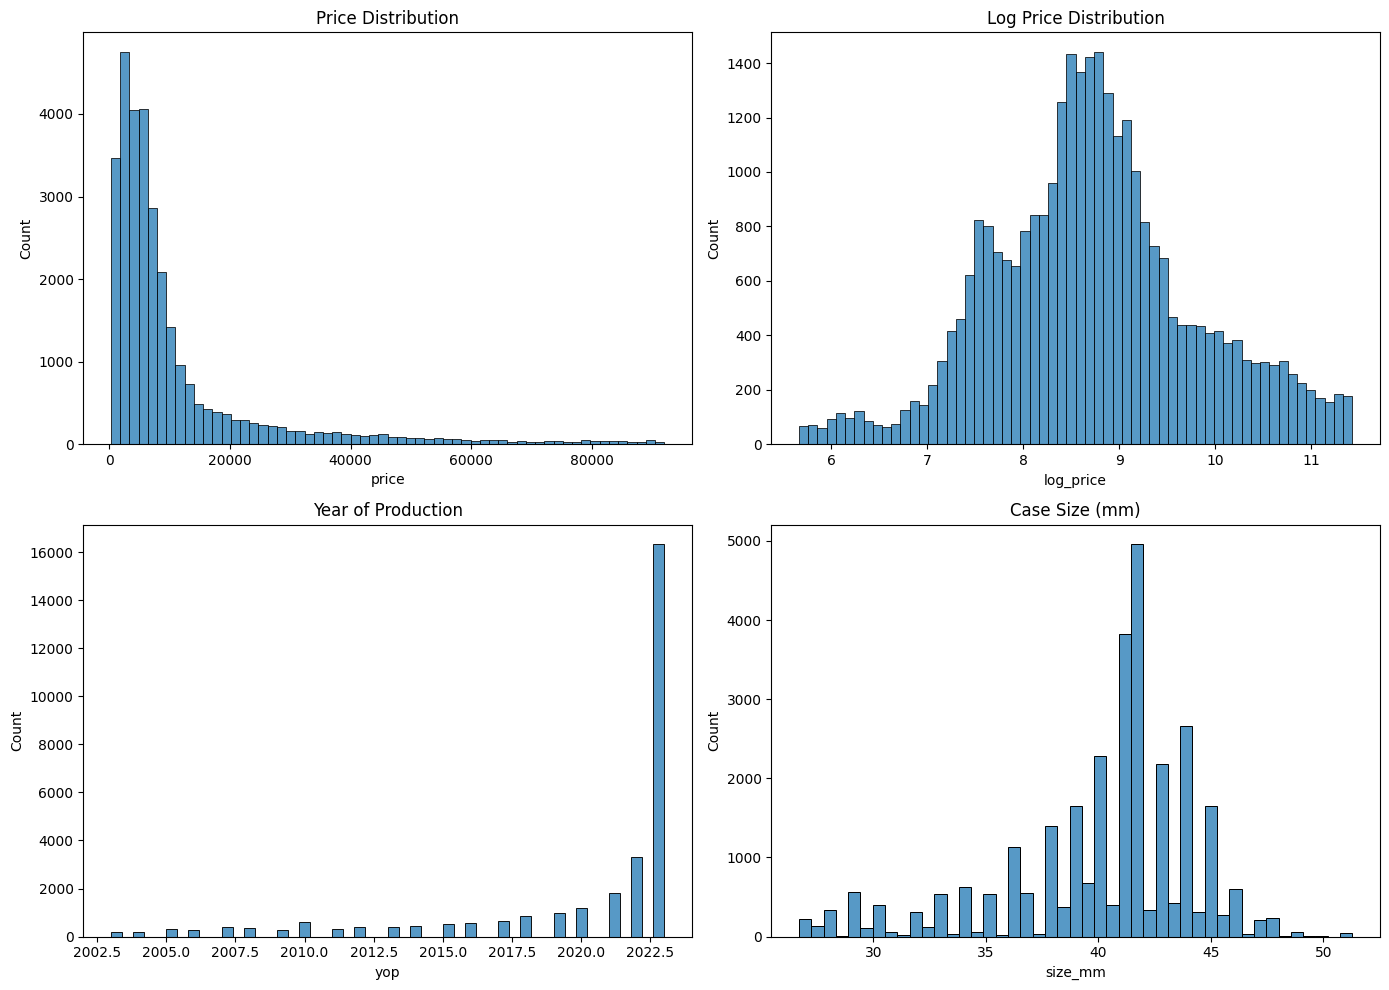

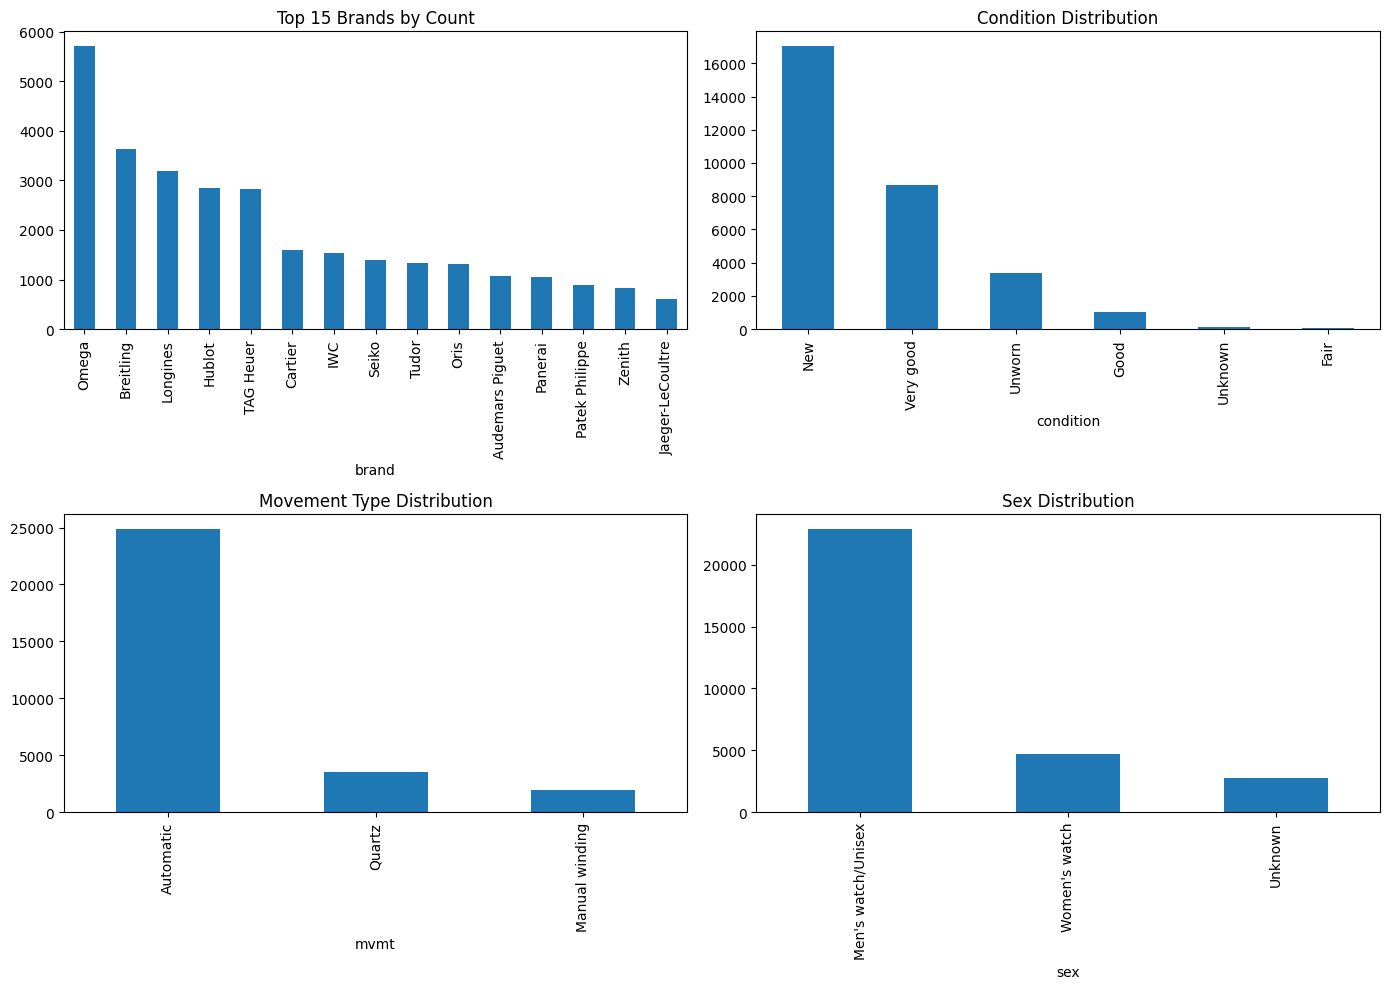

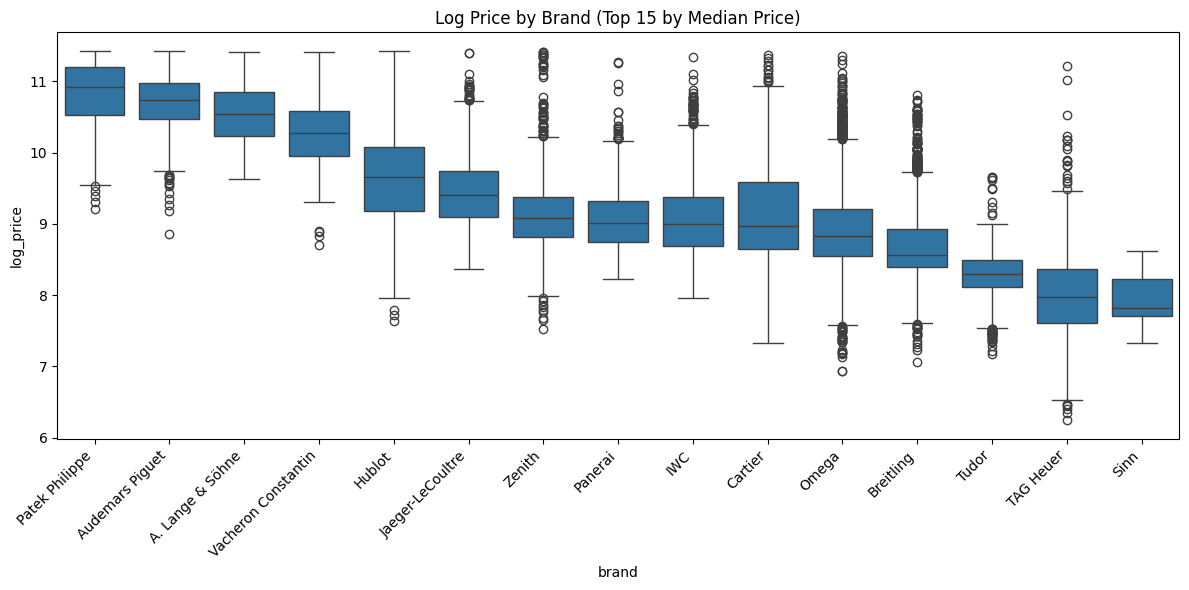

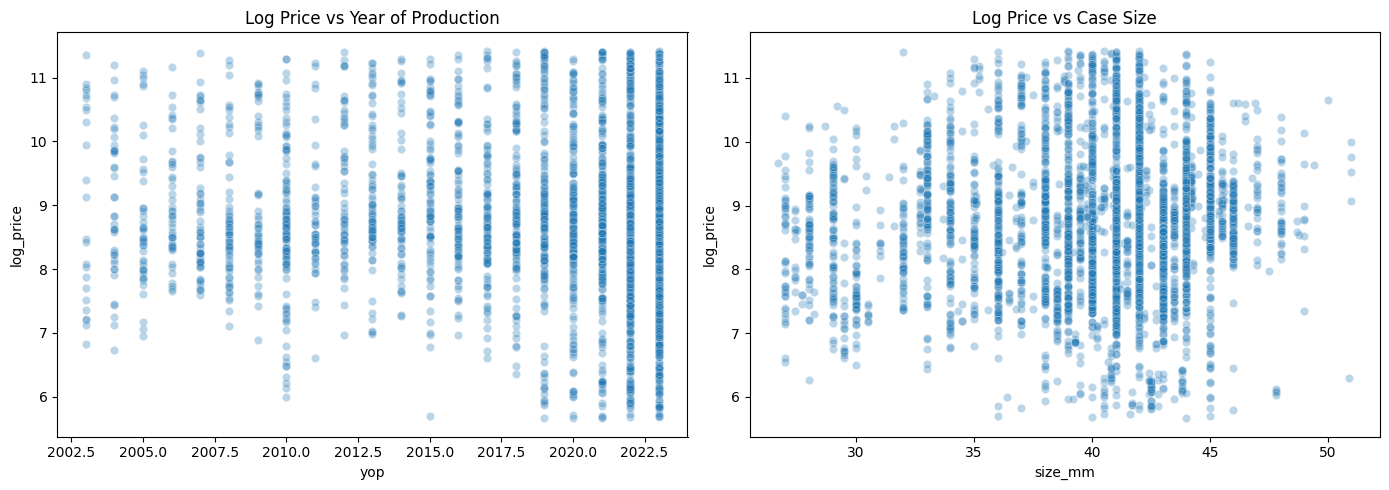

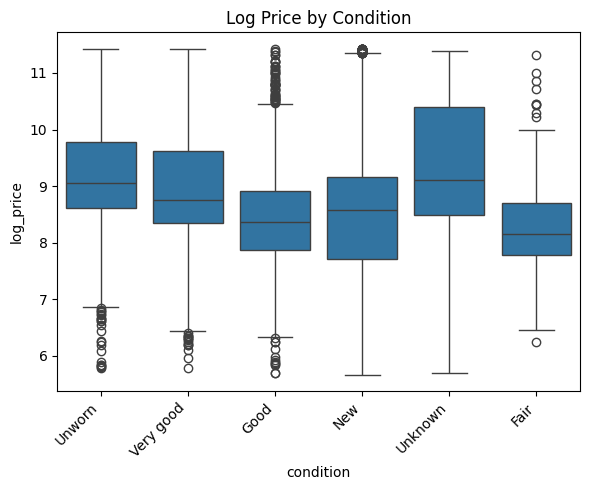

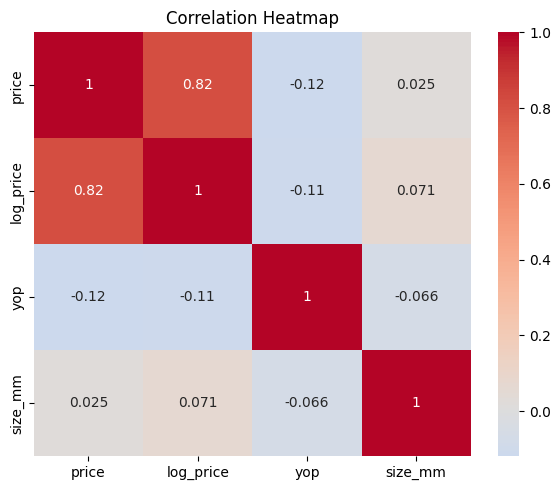

In [284]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['price'], bins=60, ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution')
sns.histplot(df['log_price'], bins=60, ax=axes[0, 1])
axes[0, 1].set_title('Log Price Distribution')
sns.histplot(df['yop'].dropna(), bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Year of Production')
sns.histplot(df['size_mm'].dropna(), bins=45, ax=axes[1, 1])
axes[1, 1].set_title('Case Size (mm)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['brand'].value_counts().head(15).plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Top 15 Brands by Count')
df['condition'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Condition Distribution')
df['mvmt'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Movement Type Distribution')
df['sex'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Sex Distribution')
plt.tight_layout()
plt.show()

top_brands = df.groupby('brand')['price'].median().sort_values(ascending=False).head(15).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='log_price', order=top_brands)
plt.xticks(rotation=45, ha='right')
plt.title('Log Price by Brand (Top 15 by Median Price)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(min(5000, len(df))), x='yop', y='log_price', alpha=0.3, ax=axes[0])
axes[0].set_title('Log Price vs Year of Production')
sns.scatterplot(data=df.sample(min(5000, len(df))), x='size_mm', y='log_price', alpha=0.3, ax=axes[1])
axes[1].set_title('Log Price vs Case Size')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='condition', y='log_price')
plt.xticks(rotation=45, ha='right')
plt.title('Log Price by Condition')
plt.tight_layout()
plt.show()

numeric_cols = ['price', 'log_price', 'yop', 'size_mm']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [285]:
import re
from collections import Counter

sample_df = df[['name', 'brand', 'model']].dropna(subset=['name']).head(50000)

def remove_brand_model(row):
    text = row['name'].replace('\n', ' ')
    for val in [row['brand'], row['model']]:
        if pd.notnull(val):
            text = re.sub(re.escape(val), '', text, flags=re.IGNORECASE)
    return text

cleaned = sample_df.apply(remove_brand_model, axis=1)

words = cleaned.str.split().sum()
words = [w.lower().strip('.,()-\'"') for w in words]
words = [w for w in words if w and not any(c.isdigit() for c in w)]
word_counts = Counter(words)

top_25 = pd.DataFrame(word_counts.most_common(25), columns=['word', 'count'])
print(top_25)

           word  count
0     automatic   3190
1         watch   2991
2   chronograph   2671
3          dial   2301
4         steel   2152
5            mm   1922
6        master   1814
7   chronometer   1805
8          gold   1762
9      co-axial   1709
10          box   1448
11        black   1415
12         blue   1189
13       papers   1152
14      edition    951
15    stainless    847
16          new    728
17        white    721
18      limited    707
19        men's    696
20           de    692
21     titanium    642
22         rose    641
23         full    627
24          set    625


In [286]:
import re
from collections import Counter

MATERIAL_LIST = ['steel', 'gold', 'titanium', 'platinum', 'ceramic', 'carbon', 'bronze',
                  'rubber', 'leather', 'rose gold', 'white gold', 'yellow gold', 'silver',
                  'sapphire', 'aluminum', 'aluminium', 'tantalum', 'palladium']

MATERIAL_SUFFIXES = ['steel', 'gold', 'titanium', 'ceramic', 'carbon', 'bronze']

def extract_material(name):
    if not isinstance(name, str):
        return 'unknown'
    text = name.lower()

    for word in text.split():
        for suffix in MATERIAL_SUFFIXES:
            if word.endswith(suffix):
                return suffix

    return 'unknown'

df['material'] = df['name'].apply(extract_material)

material_counts = df['material'].value_counts()
print(material_counts)

material
unknown     25258
steel        2283
gold         1745
titanium      649
ceramic       308
bronze        114
carbon         55
Name: count, dtype: int64


In [287]:
keywords = 'limited|anniversary|edition'
count = df['name'].str.lower().str.contains(keywords, case=False, na=False, regex=True).sum()
print(f"Total mentions: {count}")

Total mentions: 1302


In [288]:
keywords = 'papers|box|full set'
count = df['name'].str.lower().str.contains(keywords, case=False, na=False, regex=True).sum()
print(f"Total mentions: {count}")

Total mentions: 2360


In [289]:
keywords = 'king|royal|luxury|exclusive|elite|prestige'
count = df['name'].str.lower().str.contains(keywords, case=False, na=False, regex=True).sum()
print(f"Total mentions: {count}")

Total mentions: 2325


In [290]:
print(df['condition'].value_counts())

condition
New          17069
Very good     8700
Unworn        3385
Good          1048
Unknown        125
Fair            85
Name: count, dtype: int64


# Feature Engineering

In [291]:
list(df.columns)

['name',
 'price',
 'brand',
 'model',
 'ref',
 'mvmt',
 'casem',
 'bracem',
 'yop',
 'sex',
 'condition',
 'yop_approx',
 'size_mm',
 'log_price',
 'material']

- **name** — List Name - drop, or find sellers tricks
- **price** — Price of Watch
- **brand** — Brand of Watch - transform into separate columns
- **model** — Model of Brand – possiable take: usage of Luxury words, number of words
- **ref** — Reference Number - get info from number or drop
- **mvmt** — Movement Type – transform to separate columns
- **casem** — Case Material – transform to separate columns
- **bracem** — Bracelet Material – transform to separate columns
- **yop** — Year of Production – same
- **sex** — Gender / Sex – transform to separate columns
- **condition** — Condition - make unknown as separate column and rest (from 0 to 5)
- **yop_approx** — Year of Production is Approximate (flag) – 1/0 just flag that watches year is Approximated.
- **size_mm** — Case Size (mm) – as it is.
- **log_price** — Log-Transformed Price – Target.

In [292]:
CONDITION_ORDER = {
    'Incomplete': 0, 'Poor': 1, 'Fair': 2, 'Good': 3,
    'Very good': 4, 'New': 5, 'Unworn': 6,
}

COLOR_HUE = {
    'red': 0, 'orange': 30, 'salmon': 10, 'brown': 25, 'copper': 20, 'bronze': 30,
    'yellow': 55, 'gold': 50, 'champagne': 45, 'khaki': 55, 'olive': 80,
    'green': 120, 'teal': 175, 'blue': 210, 'navy': 220,
    'purple': 280, 'pink': 330, 'burgundy': 350,
}
COLOR_LIGHTNESS = {
    'black': 0.05, 'anthracite': 0.2, 'grey': 0.5, 'gray': 0.5, 'brown': 0.3,
    'burgundy': 0.25, 'navy': 0.2, 'bronze': 0.4, 'copper': 0.45, 'olive': 0.35,
    'red': 0.45, 'purple': 0.35, 'blue': 0.45, 'green': 0.4, 'teal': 0.45,
    'gold': 0.6, 'orange': 0.55, 'yellow': 0.7, 'khaki': 0.65, 'pink': 0.75,
    'salmon': 0.75, 'champagne': 0.85, 'beige': 0.85, 'ivory': 0.92, 'silver': 0.85,
    'white': 0.98,
}
ACHROMATIC = {'black', 'white', 'grey', 'gray', 'silver', 'anthracite', 'ivory', 'beige'}
COLOR_LIST = list(set(COLOR_HUE) | set(COLOR_LIGHTNESS))


def extract_color(name):
    if not isinstance(name, str):
        return 'unknown'
    text = name.lower()
    for color in COLOR_LIST:
        if re.search(rf'\b{color}\b', text):
            return color
    return 'unknown'


def add_numeric_features(df):
    df['watch_age'] = CURRENT_YEAR - df['yop']
    df['size_mm'] = df['size_mm'].fillna(df.groupby('sex')['size_mm'].transform('median'))
    df['size_mm'] = df['size_mm'].fillna(df['size_mm'].median())

    df['yop'] = df['yop'].fillna(df['yop'].median())
    df['watch_age'] = df['watch_age'].fillna(df['watch_age'].median())
    return df


def add_condition_features(df):
    df['condition_score'] = df['condition'].map(CONDITION_ORDER)
    df['condition_score'] = df['condition_score'].fillna(df['condition_score'].median())
    return df


def add_material_features(df):
    df['same_material'] = (df['casem'] == df['bracem']).astype(int)
    gold_pattern = 'gold|platinum'
    df['precious_case'] = df['casem'].str.contains(gold_pattern, case=False, na=False).astype(int)
    df['precious_brace'] = df['bracem'].str.contains(gold_pattern, case=False, na=False).astype(int)
    return df


def add_name_features(df):
    name_filled = df['name'].fillna('')
    df['name_missing'] = df['name'].isna().astype(int)
    df['has_limited'] = name_filled.str.contains('limited|anniversary|edition|remaster|re-edition', case=False).astype(int)
    df['has_papers'] = name_filled.str.contains('papers|box|full set', case=False).astype(int)
    df['has_wealthy_words'] = name_filled.str.contains('king|royal|luxury|exclusive|elite|prestige', case=False).astype(int)
    return df


def add_color_features(df):
    df['color'] = df['name'].apply(extract_color)
    df['color_has_hue'] = df['color'].apply(lambda c: 0 if c in ACHROMATIC or c == 'unknown' else 1)
    hue_deg = df['color'].map(COLOR_HUE).fillna(0)
    df['color_hue_sin'] = np.where(df['color_has_hue'] == 1, np.sin(np.radians(hue_deg)), 0)
    df['color_hue_cos'] = np.where(df['color_has_hue'] == 1, np.cos(np.radians(hue_deg)), 0)
    df['color_lightness'] = df['color'].map(COLOR_LIGHTNESS).fillna(0.5)
    return df


def add_frequency_features(df, rare_brand_threshold=100):
    rare_brands = df['brand'].value_counts()[df['brand'].value_counts() < rare_brand_threshold].index
    df['brand'] = df['brand'].replace(rare_brands, 'Other')
    return df


raw_cols = ['name', 'price', 'brand', 'model', 'ref', 'mvmt', 'casem', 'bracem',
            'yop', 'sex', 'condition', 'size_mm', 'log_price']

new_df = df[raw_cols].copy()

new_df = add_numeric_features(new_df)
new_df = add_condition_features(new_df)
new_df = add_material_features(new_df)
new_df = add_name_features(new_df)
new_df = add_color_features(new_df)
new_df = add_frequency_features(new_df)

drop_cols = ['name', 'model', 'ref', 'price', 'color', 'yop', 'condition']
X = new_df.drop(columns=drop_cols + ['log_price'])
y = new_df['log_price']

category_cols = ['brand', 'mvmt', 'casem', 'bracem', 'sex']

print(f"new_df shape: {new_df.shape}")
print(f"new_df columns: {new_df.columns.tolist()}")
print(f"\nX shape: {X.shape}")
print(f"Categorical columns (kept as-is, not encoded): {category_cols}")
print(f"Any NaN left: {X.isnull().sum().sum()}")
print(f"\nTop correlations with log_price:\n{new_df[X.select_dtypes(include=np.number).columns.tolist() + ['log_price']].corr()['log_price'].abs().sort_values(ascending=False).head(20)}")

new_df shape: (30412, 27)
new_df columns: ['name', 'price', 'brand', 'model', 'ref', 'mvmt', 'casem', 'bracem', 'yop', 'sex', 'condition', 'size_mm', 'log_price', 'watch_age', 'condition_score', 'same_material', 'precious_case', 'precious_brace', 'name_missing', 'has_limited', 'has_papers', 'has_wealthy_words', 'color', 'color_has_hue', 'color_hue_sin', 'color_hue_cos', 'color_lightness']

X shape: (30412, 19)
Categorical columns (kept as-is, not encoded): ['brand', 'mvmt', 'casem', 'bracem', 'sex']
Any NaN left: 0

Top correlations with log_price:
log_price            1.000000
precious_case        0.470584
has_wealthy_words    0.280062
same_material        0.238583
color_has_hue        0.177124
color_hue_sin        0.159381
precious_brace       0.145070
watch_age            0.106808
color_hue_cos        0.095904
has_papers           0.094273
color_lightness      0.089796
size_mm              0.070679
has_limited          0.019464
condition_score      0.005112
name_missing             

In [293]:
for col in category_cols:
    X[col] = X[col].astype('category')

# PREDICTION MODEL

In [294]:
from sklearn.model_selection import train_test_split

category_cols = ['brand', 'mvmt', 'casem', 'bracem', 'sex']

for col in category_cols:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (24329, 19)
Test shape: (6083, 19)


In [295]:
# @title
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    categorical_feature=category_cols,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

y_pred_log = model.predict(X_test)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"\n--- Evaluation (log space) ---")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE (log): {mae_log:.4f}")
print(f"R²: {r2:.4f}")

print(f"\n--- Evaluation (actual price, $) ---")
print(f"RMSE: ${rmse_actual:,.0f}")
print(f"MAE: ${mae_actual:,.0f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 276
[LightGBM] [Info] Number of data points in the train set: 24329, number of used features: 18
[LightGBM] [Info] Start training from score 8.729422
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 0.145636
[100]	valid_0's l2: 0.118614
[150]	valid_0's l2: 0.111802
[200]	valid_0's l2: 0.108081
[250]	valid_0's l2: 0.105781
[300]	valid_0's l2: 0.104342
[350]	valid_0's l2: 0.103002
[400]	valid_0's l2: 0.102018
[450]	valid_0's l2: 0.101174
[500]	valid_0's l2: 0.100696
Did not meet early stopping. Best iteration is:
[499]	valid_0's l2: 0.100689

--- Evaluation (log space) ---
RMSE (log): 0.3173
MAE (log): 0.2284
R²: 0.9141

--- Evaluation (actual price, $) ---
RMSE: $5,576
MAE: $2,539


size_mm              4089
watch_age            2412
brand                2076
mvmt                 1087
bracem                833
casem                 829
condition_score       737
color_lightness       485
sex                   463
same_material         417
has_wealthy_words     301
precious_case         274
has_limited           247
color_hue_cos         216
color_hue_sin         184
has_papers            113
color_has_hue         108
precious_brace         99
name_missing            0
dtype: int32


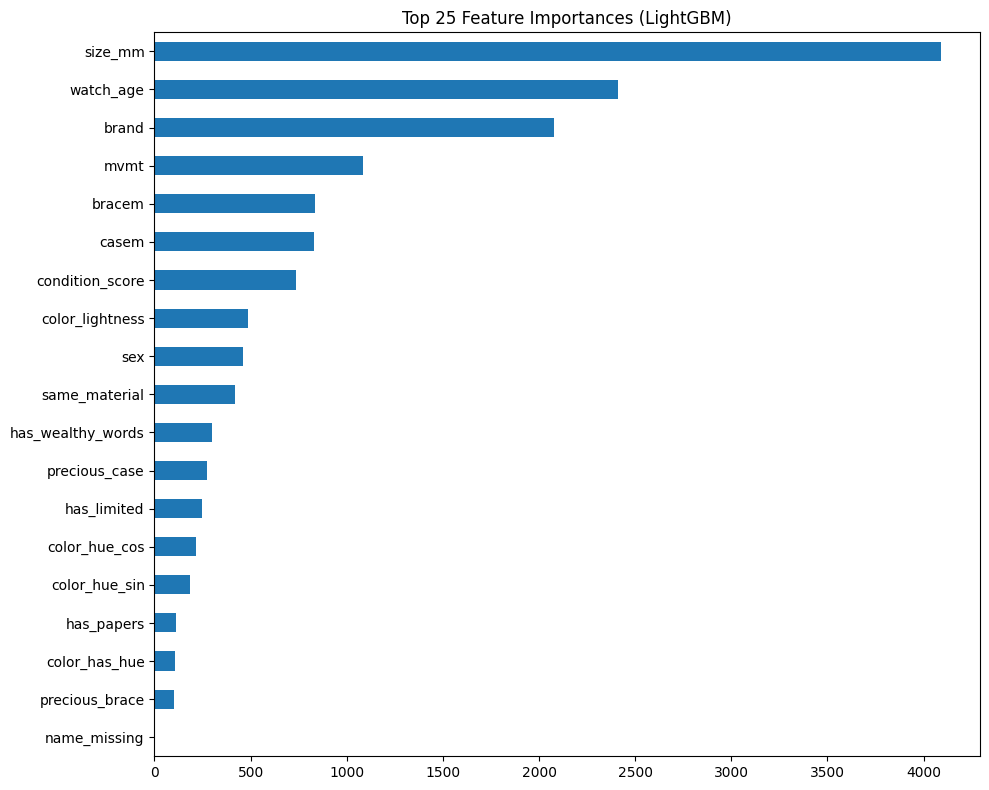

In [296]:
# @title
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(25))

plt.figure(figsize=(10, 8))
importances.head(25).sort_values().plot(kind='barh')
plt.title('Top 25 Feature Importances (LightGBM)')
plt.tight_layout()
plt.show()

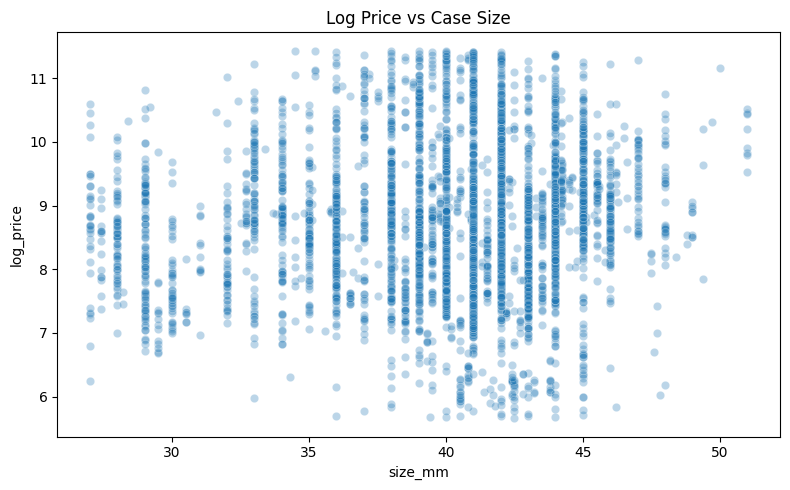

In [306]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=new_df.sample(min(5000, len(new_df))), x='size_mm', y='log_price', alpha=0.3)
plt.title('Log Price vs Case Size')
plt.tight_layout()
plt.show()

In [307]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
perm_importance = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(perm_importance.head(20))

brand                1.297627
casem                0.112722
mvmt                 0.053004
size_mm              0.051333
watch_age            0.026300
condition_score      0.016371
bracem               0.013726
has_wealthy_words    0.005157
has_limited          0.005145
precious_case        0.004922
sex                  0.003664
color_lightness      0.002421
precious_brace       0.001943
same_material        0.001298
color_hue_cos        0.000506
color_hue_sin        0.000298
has_papers           0.000188
color_has_hue        0.000040
name_missing         0.000000
dtype: float64


In [299]:
# @title
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
mae_log = mean_absolute_error(y_test, y_pred_log)
r2 = r2_score(y_test, y_pred_log)

y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)
rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)

print(f"--- Evaluation (log space) ---")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE (log): {mae_log:.4f}")
print(f"R²: {r2:.4f}")

print(f"\n--- Evaluation (actual price, $) ---")
print(f"RMSE: ${rmse_actual:,.0f}")
print(f"MAE: ${mae_actual:,.0f}")

--- Evaluation (log space) ---
RMSE (log): 0.3173
MAE (log): 0.2284
R²: 0.9141

--- Evaluation (actual price, $) ---
RMSE: $5,576
MAE: $2,539


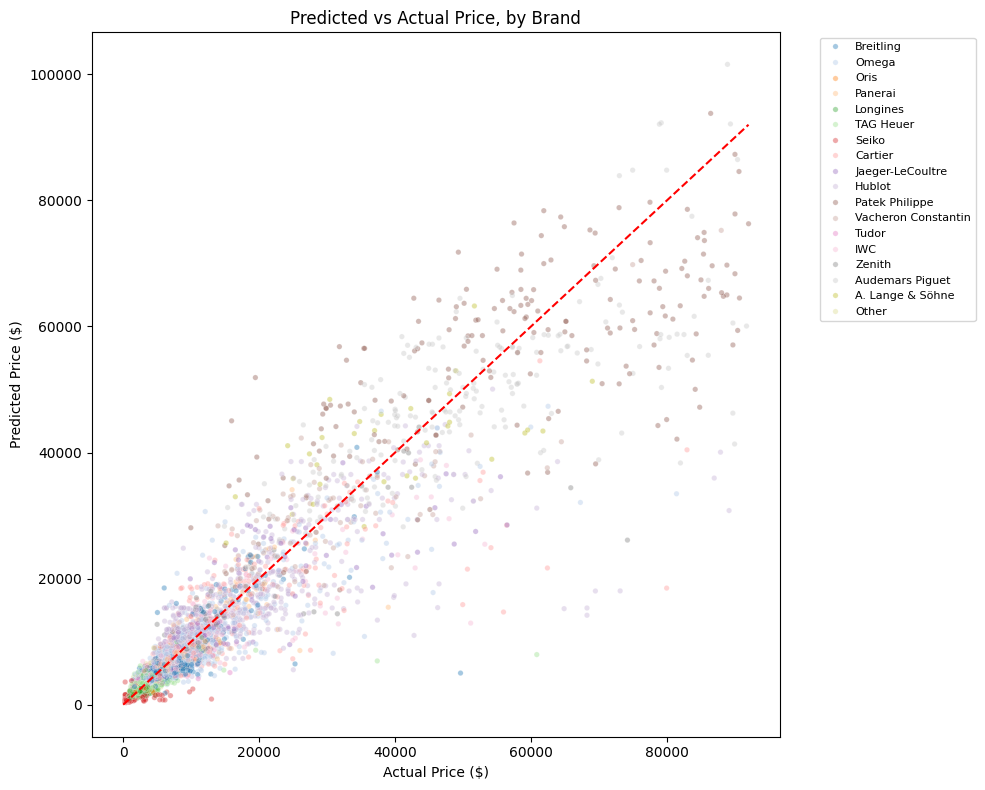

                    abs_pct_error
actual                           
(286.999, 2453.0]       29.583497
(2453.0, 4799.8]        22.378979
(4799.8, 7360.0]        19.821184
(7360.0, 13845.2]       21.670491
(13845.2, 92000.0]      23.737588

Overall median % error: 17.4%


In [300]:
# @title
residuals_df = pd.DataFrame({
    'actual': y_test_actual,
    'predicted': y_pred_actual,
    'error': y_pred_actual - y_test_actual,
    'abs_pct_error': np.abs((y_pred_actual - y_test_actual) / y_test_actual) * 100
})
residuals_df['brand'] = new_df.loc[X_test.index, 'brand'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(data=residuals_df, x='actual', y='predicted', hue='brand', alpha=0.4, s=15, palette='tab20')
max_val = residuals_df['actual'].max()
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Price, by Brand')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

price_bins = pd.qcut(residuals_df['actual'], q=5)
print(residuals_df.groupby(price_bins)[['abs_pct_error']].mean())
print(f"\nOverall median % error: {residuals_df['abs_pct_error'].median():.1f}%")

In [301]:
perm_threshold = 0.003

final_features = perm_importance[perm_importance > perm_threshold].index.tolist()
dropped_features = perm_importance[perm_importance <= perm_threshold].index.tolist()

print(f"Features kept ({len(final_features)}): {final_features}")
print(f"\nFeatures dropped ({len(dropped_features)}): {dropped_features}")

X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

category_cols_final = [c for c in category_cols if c in final_features]

final_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_final, y_train,
    eval_set=[(X_test_final, y_test)],
    categorical_feature=category_cols_final,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

y_pred_log_final = final_model.predict(X_test_final)

rmse_log_final = np.sqrt(mean_squared_error(y_test, y_pred_log_final))
mae_log_final = mean_absolute_error(y_test, y_pred_log_final)
r2_final = r2_score(y_test, y_pred_log_final)

y_pred_actual_final = np.expm1(y_pred_log_final)
rmse_actual_final = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_final))
mae_actual_final = mean_absolute_error(y_test_actual, y_pred_actual_final)

print(f"\n--- Final model ({len(final_features)} features) ---")
print(f"RMSE (log): {rmse_log_final:.4f}")
print(f"MAE (log): {mae_log_final:.4f}")
print(f"R²: {r2_final:.4f}")
print(f"RMSE ($): ${rmse_actual_final:,.0f}")
print(f"MAE ($): ${mae_actual_final:,.0f}")

print(f"\n--- Original model (22 features) ---")
print(f"RMSE (log): {rmse_log:.4f}")
print(f"MAE (log): {mae_log:.4f}")
print(f"R²: {r2:.4f}")

Features kept (11): ['brand', 'casem', 'mvmt', 'size_mm', 'watch_age', 'condition_score', 'bracem', 'has_wealthy_words', 'has_limited', 'precious_case', 'sex']

Features dropped (8): ['color_lightness', 'precious_brace', 'same_material', 'color_hue_cos', 'color_hue_sin', 'has_papers', 'color_has_hue', 'name_missing']
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 24329, number of used features: 11
[LightGBM] [Info] Start training from score 8.729422
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l2: 0.146432
[100]	valid_0's l2: 0.11954
[150]	valid_0's l2: 0.112468
[200]	valid_0's l2: 0.109228
[250]	valid_0's l2: 0.106971
[300]	valid_0's l2: 0.105165
[350]	valid_0's l2: 0.10401
[400]	valid_0's

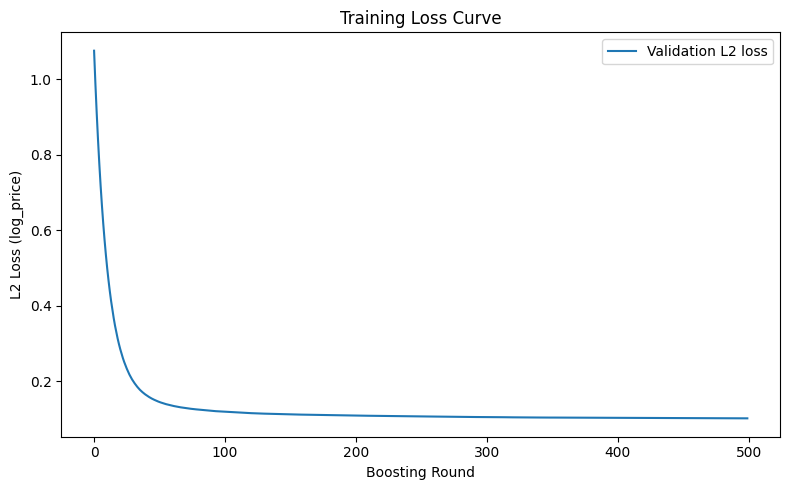

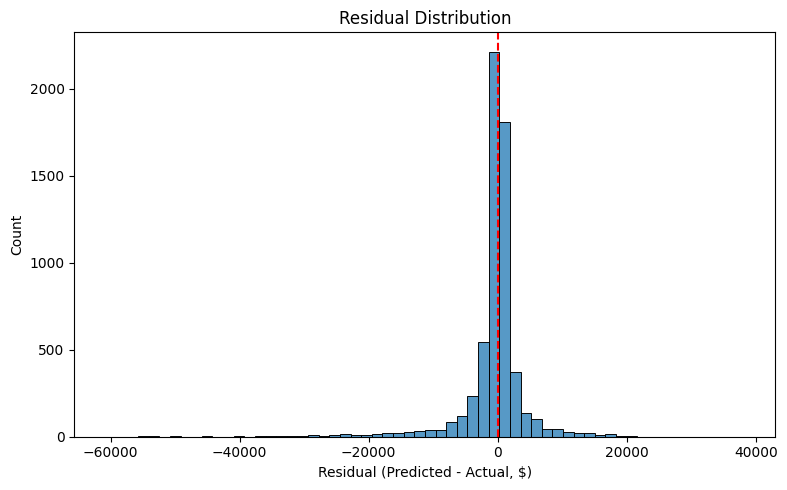

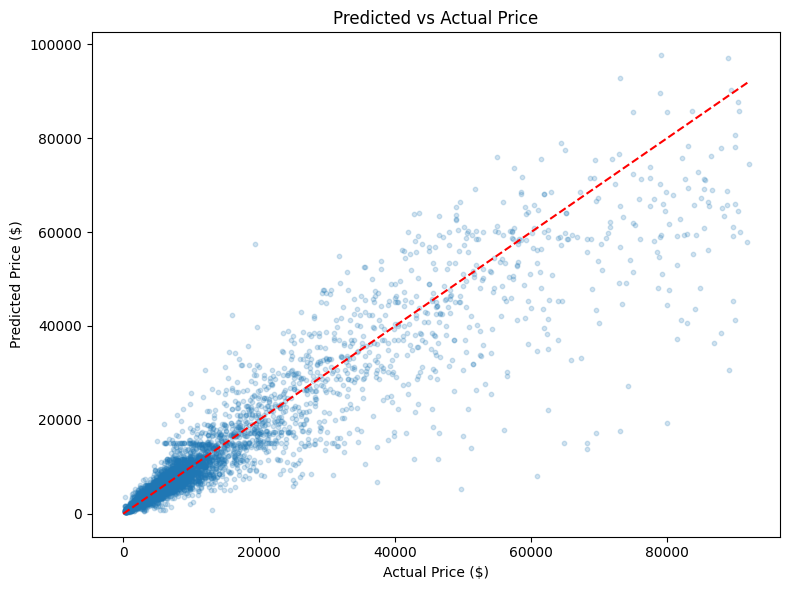

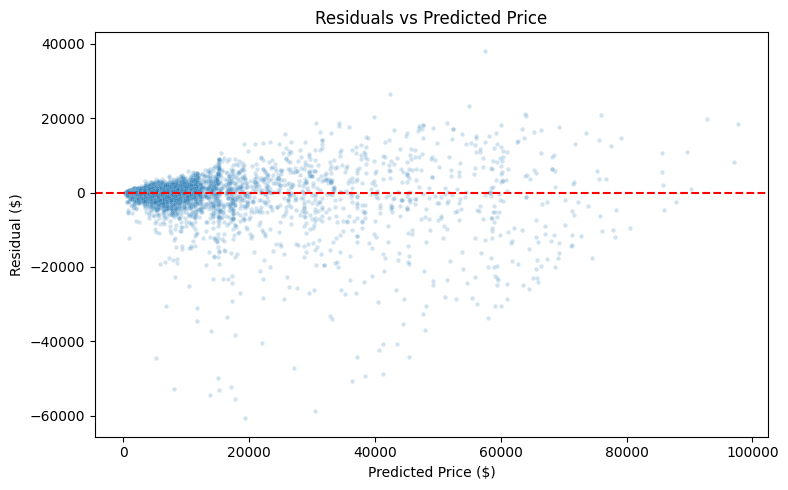

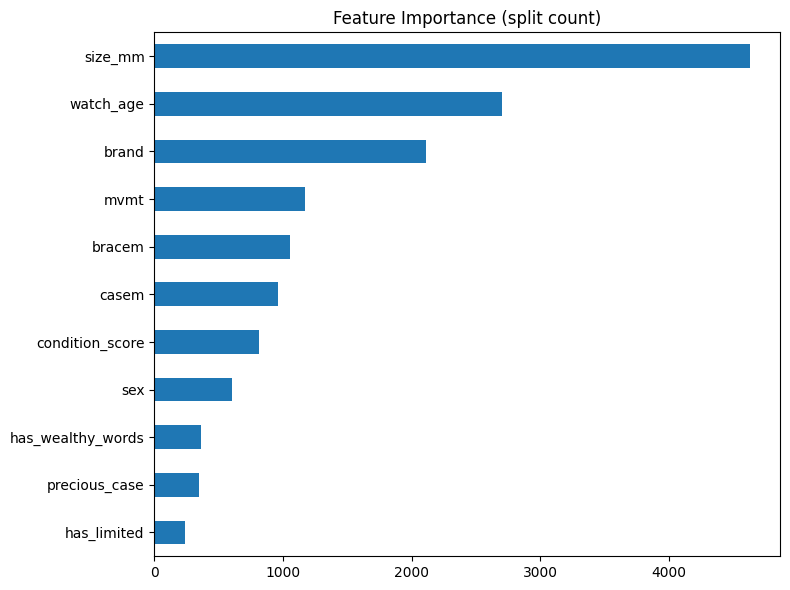

--- Final model (11 features) ---
RMSE (log): 0.3192
MAE (log): 0.2299
R²: 0.9130
RMSE ($): $5,548
MAE ($): $2,536


In [302]:
eval_results = final_model.evals_result_

plt.figure(figsize=(8, 5))
plt.plot(eval_results['valid_0']['l2'], label='Validation L2 loss')
plt.xlabel('Boosting Round')
plt.ylabel('L2 Loss (log_price)')
plt.title('Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_pred_actual_final - y_test_actual

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (Predicted - Actual, $)')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual_final, alpha=0.2, s=10)
max_val = y_test_actual.max()
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Price')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_actual_final, y=residuals, alpha=0.2, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residuals vs Predicted Price')
plt.tight_layout()
plt.show()

importances = pd.Series(final_model.feature_importances_, index=final_features).sort_values()
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance (split count)')
plt.tight_layout()
plt.show()

print(f"--- Final model ({len(final_features)} features) ---")
print(f"RMSE (log): {rmse_log_final:.4f}")
print(f"MAE (log): {mae_log_final:.4f}")
print(f"R²: {r2_final:.4f}")
print(f"RMSE ($): ${rmse_actual_final:,.0f}")
print(f"MAE ($): ${mae_actual_final:,.0f}")

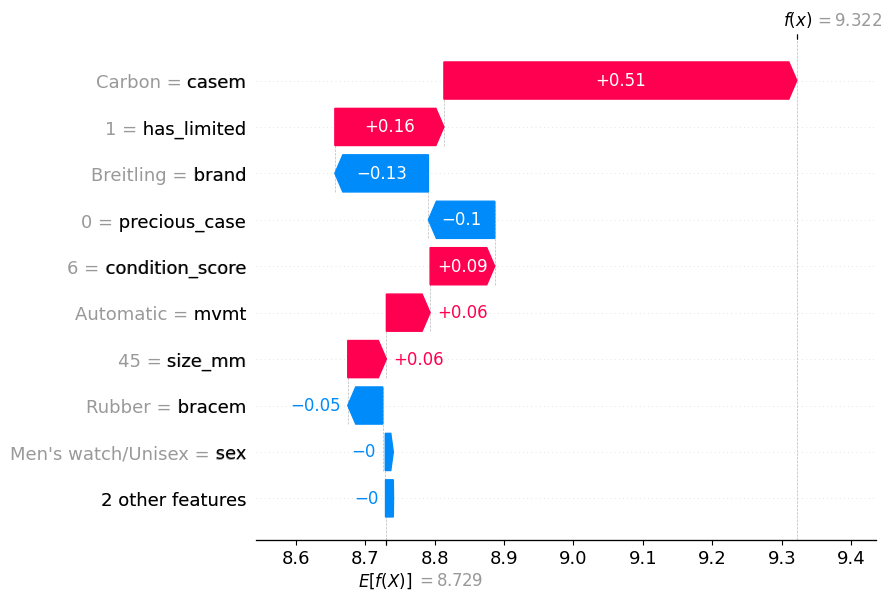

In [308]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_final)
shap.plots.waterfall(shap_values[0])

# Post-prediction Analitics

In [309]:
residuals_df['brand'] = new_df.loc[X_test.index, 'brand'].values
print(residuals_df.groupby('brand')['abs_pct_error'].mean().sort_values(ascending=False))

brand
Other                  86.262694
Seiko                  55.409626
Hublot                 28.607900
A. Lange & Söhne       28.270696
Patek Philippe         26.717134
TAG Heuer              25.134158
Cartier                24.001079
Jaeger-LeCoultre       22.374002
Vacheron Constantin    22.216717
Breitling              21.973402
Longines               20.369183
IWC                    20.109319
Omega                  20.048858
Zenith                 19.509221
Tudor                  18.199916
Panerai                18.112884
Audemars Piguet        17.920751
Oris                   16.950663
Name: abs_pct_error, dtype: float64


In [310]:
# @title
for feature in ['condition_score', 'watch_age', 'size_mm']:
    if feature not in residuals_df.columns:
        residuals_df[feature] = new_df.loc[X_test.index, feature].values

worst_n = int(len(residuals_df) * 0.10)
worst = residuals_df.nlargest(worst_n, 'abs_pct_error')
rest = residuals_df.drop(worst.index)

print(f"Worst 10% of predictions: {len(worst)} rows")
print(f"Median abs % error - worst group: {worst['abs_pct_error'].median():.1f}%")
print(f"Median abs % error - rest: {rest['abs_pct_error'].median():.1f}%")

print("\n--- Brand distribution ---")
print(pd.DataFrame({
    'worst_%': (worst['brand'].value_counts(normalize=True) * 100).round(1),
    'rest_%': (rest['brand'].value_counts(normalize=True) * 100).round(1)
}).fillna(0).sort_values('worst_%', ascending=False))

print("\n--- Numeric feature comparison (mean) ---")
for feature in ['condition_score', 'watch_age', 'size_mm', 'actual']:
    print(f"{feature}: worst={worst[feature].mean():.2f}, rest={rest[feature].mean():.2f}")

for extra_col in ['casem', 'bracem', 'mvmt', 'sex', 'condition']:
    worst_vals = new_df.loc[worst.index, extra_col]
    rest_vals = new_df.loc[rest.index, extra_col]
    print(f"\n--- {extra_col} distribution ---")
    print(pd.DataFrame({
        'worst_%': (worst_vals.value_counts(normalize=True) * 100).round(1),
        'rest_%': (rest_vals.value_counts(normalize=True) * 100).round(1)
    }).fillna(0).sort_values('worst_%', ascending=False).head(10))

print(f"\nDirection of errors in worst group: {(worst['error'] > 0).sum()} overpredicted, {(worst['error'] < 0).sum()} underpredicted")

Worst 10% of predictions: 608 rows
Median abs % error - worst group: 63.3%
Median abs % error - rest: 15.1%

--- Brand distribution ---
                     worst_%  rest_%
brand                               
Hublot                  16.9     8.7
Seiko                   16.3     3.1
Omega                   12.0    18.5
TAG Heuer               10.5     9.5
Longines                 8.6    11.2
Cartier                  7.6     5.2
Breitling                6.9    12.3
IWC                      4.3     5.2
Patek Philippe           3.8     3.0
Tudor                    2.3     4.1
Zenith                   1.8     2.6
Jaeger-LeCoultre         1.8     2.2
Oris                     1.8     5.0
Panerai                  1.3     4.1
Other                    1.3     0.0
Audemars Piguet          1.2     3.5
Vacheron Constantin      1.0     1.4
A. Lange & Söhne         0.7     0.5

--- Numeric feature comparison (mean) ---
condition_score: worst=4.67, rest=4.76
watch_age: worst=6.46, rest=5.84
size_mm: 